## Bagging

In this part we aggregate regression trees by bagging: each tree is grown without pruning on a bootstrap sample of the rows, and the prediction is the mean of the trees. Averaging reduces the variance of the fully grown trees, which overfit their training rows (see the pruned CART notebook).

### Main observations

- **Number of trees:** A single bagged tree has a validation MAE 31% to 55% above that of 500 trees. The curves are flat from 50 trees on, and 200 trees are kept, within 1% of 500 trees.
- **max_samples, max_features:** The best bagging is the classic one for every target: each tree gets a bootstrap sample as large as the train folds, and all the inputs. Fewer rows or fewer inputs per tree always increase the MAE.
- **Results:** MAE of 35.2 MPa on the yield strength, 30.9 MPa on the UTS, 1.95% on the elongation and 19.1 J on the Charpy energy: 25% to 27% below the pruned tree on the tensile targets, no gain on Charpy. On the label, F1 of 0.81 (0.77 for the pruned tree) and recall of 0.72 (0.81).
- **Smoothed predictions:** The predictions spread 18% to 19% less than the measures. The bagging predicts fewer failures than there are: it misses more bad welds but raises fewer false alarms. On Charpy, only 6 rows are predicted below the threshold for 29 non-conforming, and the recall falls from 0.62 (pruned tree) to 0.10.

### Operations in order

1. Load the train set with `load_train`.
2. Plot the validation MAE against the number of trees, to fix `n_estimators`.
3. Tune `max_samples` (share of the rows drawn for each tree) and `max_features` (share of the inputs given to each tree) per target by a grid search on the folds of `helpers/utils.py`.
4. Evaluate the best model of each target with `evaluate`, and compare the spread of its predictions with the measures.
5. Save it to `results.csv` and compare it with the baseline and the pruned tree.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, validation_curve

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    SEED, TARGETS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, evaluate, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()

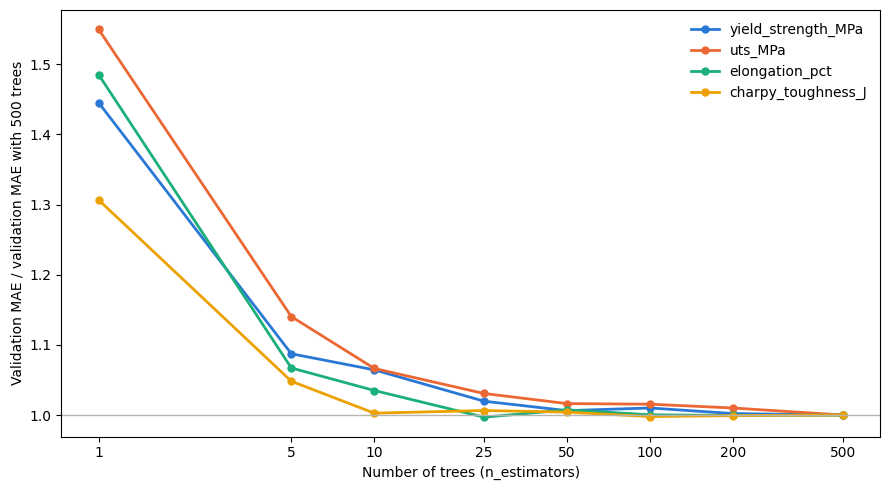

,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J
n_estimators,,,,
1,50.76,47.27,2.89,25.00
5,38.18,34.78,2.08,20.06
10,37.38,32.53,2.02,19.19
25,35.81,31.44,1.94,19.26
50,35.34,31.00,1.96,19.22
100,35.47,30.97,1.95,19.09
200,35.19,30.81,1.95,19.12
500,35.12,30.50,1.95,19.14


In [4]:
n_trees = [1, 5, 10, 25, 50, 100, 200, 500]

curves = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    _, val_scores = validation_curve(
        build_pipeline(BaggingRegressor(DecisionTreeRegressor(), random_state=SEED)),
        X, y,
        param_name="model__n_estimators",
        param_range=n_trees,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    curves[target] = -val_scores.mean(axis=1)
curves = pd.DataFrame(curves, index=pd.Index(n_trees, name="n_estimators"))

fig, ax = plt.subplots(figsize=(9, 5))
for color, target in zip(["#2a78d6", "#eb6834", "#1baf7a", "#eda100"], TARGETS):
    ax.plot(n_trees, curves[target] / curves[target].iloc[-1], color=color, linewidth=2, marker="o", markersize=5, label=target)
ax.axhline(1, color="#b5b4ae", linewidth=1)
ax.set_xscale("log")
ax.set_xticks(n_trees, n_trees)
ax.minorticks_off()
ax.set_xlabel("Number of trees (n_estimators)")
ax.set_ylabel("Validation MAE / validation MAE with 500 trees")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

curves.round(2)

`validation_curve` fits the bagging on the train folds for each number of trees, and returns the MAE on the validation fold, averaged over the 5 folds. The figure divides each curve by its value at 500 trees, so that the four targets share one axis.

- **1 tree:** A single tree grown on a bootstrap sample has a validation MAE 31% (Charpy) to 55% (UTS) above that of 500 trees. It is also a little worse than the full tree of the pruned CART notebook (50.8 against 48.4 MPa on the yield strength), as a bootstrap sample only holds about 63% of the distinct rows of the train folds.
- **More trees:** The MAE drops quickly up to 25 trees, then the curves are flat: from 50 trees on, every target is within 2% of its value at 500 trees. Adding trees reduces the variance of the mean without adding overfitting, it only costs computation time.
- **n_estimators = 200:** Kept for the grid search, within 1% of 500 trees on every target. The random forest and Extra-Trees notebooks use the same number, so that the three ensembles are compared with as many trees.
- **Out-of-bag error:** Not used, although the bagging provides it for free. The bootstrap draws rows, not deposits: a row left out of a tree can have other rows of the same deposit in the sample of that tree, so the out-of-bag error would be optimistic. The folds of `helpers/utils.py` keep each deposit in a single fold.

In [5]:
param_grid = {"model__max_samples": [0.25, 0.5, 0.75, 1.0], "model__max_features": [0.25, 0.5, 0.75, 1.0]}

searches = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    search = GridSearchCV(
        build_pipeline(BaggingRegressor(DecisionTreeRegressor(), n_estimators=200, random_state=SEED)),
        param_grid,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    search.fit(X, y)
    searches[target] = search

grid = pd.concat({
    target: pd.DataFrame(search.cv_results_).pivot(index="param_model__max_samples", columns="param_model__max_features", values="mean_test_score")
    for target, search in searches.items()
})
(-grid).rename_axis(index=["target", "max_samples"], columns="max_features").round(2)

max_features                     0.25   0.50   0.75   1.00
target             max_samples                            
yield_strength_MPa 0.25         50.05  43.54  41.06  40.26
                   0.50         47.27  40.51  37.67  36.58
                   0.75         45.91  39.49  36.15  35.32
                   1.00         45.03  38.47  35.46  35.19
uts_MPa            0.25         45.14  39.10  36.60  35.63
                   0.50         42.25  36.40  33.49  31.92
                   0.75         41.08  35.01  32.46  30.91
                   1.00         40.49  34.21  31.70  30.81
elongation_pct     0.25          2.62   2.38   2.28   2.24
                   0.50          2.51   2.23   2.13   2.04
                   0.75          2.46   2.16   2.05   1.99
                   1.00          2.43   2.14   2.04   1.95
charpy_toughness_J 0.25         31.69  28.17  25.92  23.72
                   0.50         30.69  26.46  23.41  20.87
                   0.75         30.21  25.56  22.44  19.66
                   1.00         29.86  25.05  21.86  19.12

The validation MAE of each pair (`max_samples`, `max_features`), with 200 trees. As in the TD3, `max_samples` is the number of rows drawn with replacement for each tree, as a share of the train folds, and `max_features` the share of the inputs given to each tree, drawn once per tree.

- **max_features:** The MAE goes up every time the trees get fewer inputs, whatever `max_samples`: 45.0 MPa on the yield strength with 25% of the inputs, against 35.2 MPa with all of them. With 7 inputs out of 30, 77% of the trees do not see Cr, and 44% see none of Mo, Mn and Cr, the inputs of the first splits of the pruned tree. For Charpy, 77% of the trees do not see `charpy_temp_C`, which is most likely why the MAE reaches 29.9 J against 19.1 J.
- **max_samples:** The same, the trees are better with more rows: 40.3 MPa on the yield strength with a quarter of the rows, against 35.2 MPa with all of them.
- **Best pair:** (1.0, 1.0) for the four targets, the classic bagging. With 558 to 723 rows per target, decorrelating the trees by giving them fewer rows or fewer inputs costs more accuracy than it brings.

In [6]:
best = {target: search.best_estimator_ for target, search in searches.items()}

pd.DataFrame({
    target: {**{name.removeprefix("model__"): value for name, value in search.best_params_.items()}, "validation_MAE": -search.best_score_}
    for target, search in searches.items()
}).T

,max_features,max_samples,validation_MAE
yield_strength_MPa,1.0,1.0,35.190149
uts_MPa,1.0,1.0,30.807788
elongation_pct,1.0,1.0,1.947652
charpy_toughness_J,1.0,1.0,19.120228


The best model of each target is the same: 200 fully grown trees, each on a bootstrap sample of all the rows of the train folds and with all the inputs.

In [7]:
bagging = evaluate("Bagging", best, train)
bagging.round(2)

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,Bagging,yield_strength_MPa,all,620,35.24,49.40,3.77,6.82,619,102,0.68,0.57
1,Bagging,yield_strength_MPa,C-Mn,552,33.49,44.89,2.25,4.57,552,102,0.68,0.57
2,Bagging,yield_strength_MPa,CrMo2,30,55.38,82.04,35.42,46.41,29,0,0.00,0.00
3,Bagging,yield_strength_MPa,CrMo91,38,44.78,72.36,21.94,36.23,38,0,0.00,0.00
4,Bagging,uts_MPa,all,596,30.86,44.45,3.52,8.47,595,198,0.67,0.56
5,Bagging,uts_MPa,C-Mn,531,29.26,39.60,1.59,3.45,531,198,0.67,0.56
6,Bagging,uts_MPa,CrMo2,34,50.13,77.47,27.87,41.79,33,0,0.00,0.00
7,Bagging,uts_MPa,CrMo91,31,37.09,67.39,19.07,39.26,31,0,0.00,0.00
8,Bagging,elongation_pct,all,558,1.95,2.51,0.15,0.23,557,48,0.62,0.50
9,Bagging,elongation_pct,C-Mn,497,1.94,2.50,0.16,0.24,497,37,0.67,0.57


- **MAE:** 35.2 MPa on the yield strength, 30.9 MPa on the UTS, 1.95% on the elongation and 19.1 J on the Charpy energy. On the three tensile targets, the bagging is 25% to 27% below the pruned tree. On Charpy, it is not better (19.1 against 18.9 J).
- **Per family:** On the CrMo2 welds, the MAE of the yield strength drops to 55 MPa (93 MPa for the pruned tree), below the baseline (65 MPa). On the CrMo91 welds it goes up (45 against 36 MPa), but with 38 rows and a standard deviation of 22 MPa over the folds, this difference is within the noise of the folds.
- **F1, recall per criterion:** The F1 goes up on the three tensile criteria (0.68, 0.67 and 0.62 against 0.60, 0.64 and 0.46 for the pruned tree), with the same recall or lower. On Charpy, the recall falls to 0.10: the bagging only catches 3 of the 29 non-conforming rows (the pruned tree caught 62% of them).
- **label:** F1 of 0.81 and recall of 0.72, against 0.77 and 0.81 for the pruned tree: fewer false alarms, but more missed bad welds.

In [8]:
preds = {target: oof_predict(best[target], train, target) for target in TARGETS}
criteria = true_criteria(train)
predicted = predicted_criteria(train, preds)

pd.DataFrame({
    "std_measured": [get_xy(train, target)[1].std() for target in TARGETS],
    "std_predicted": [preds[target]["pred"].std() for target in TARGETS],
    "non_conforming": (criteria == 0).sum(),
    "predicted_non_conforming": ((predicted == 0) & criteria.notna()).sum(),
}, index=TARGETS).round(1)

,std_measured,std_predicted,non_conforming,predicted_non_conforming
yield_strength_MPa,94.2,76.4,102,69
uts_MPa,91.9,75.7,198,129
elongation_pct,4.8,3.9,48,29
charpy_toughness_J,51.5,42.2,29,6


The same table as in the pruned CART notebook.

- **std_predicted:** The predictions of the bagging spread 18% to 19% less than the measures on every target: 76.4 against 94.2 MPa on the yield strength, 42.2 against 51.5 J on Charpy, where the pruned tree had 92.0 and 49.1. The mean of 200 trees is pulled toward the mean of the target, the extreme values are smoothed.
- **predicted_non_conforming:** The bagging predicts fewer failures than there are on every criterion (69 against 102 on the yield strength, 129 against 198 on the UTS), as the failures are in the tails of the targets. On the tensile criteria these fewer alarms are more often right (58 of the 69 on the yield strength), so the F1 goes up while the recall goes down. On Charpy, only 6 decided rows are predicted below the threshold at the reference temperature, for 29 non-conforming rows, hence the recall of 0.10.

In [9]:
results = save_results(bagging)

models = ["Baseline (mean)", "Pruned CART", "Bagging"]
compared = results[results["model"].isin(models) & (results["family"] == "all")].set_index(["model", "target"])
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models).reindex(columns=TARGETS, level="target").round(2))
compared[["F1_nc", "recall_nc"]].unstack().reindex(index=models).reindex(columns=TARGETS + ["label"], level="target").round(2)

MAE                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)              72.57   73.45           4.01              39.89   
Pruned CART                  48.24   41.78           2.60              18.87   
Bagging                      35.24   30.86           1.95              19.11   

                              RMSE                                            
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J  
model                                                                         
Baseline (mean)              94.41   92.19           4.85              51.73  
Pruned CART                  66.22   59.97           3.32              32.46  
Bagging                      49.40   44.45           2.51              28.16

F1_nc                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)               0.00    0.00           0.00               0.00   
Pruned CART                   0.60    0.64           0.46               0.52   
Bagging                       0.68    0.67           0.62               0.17   

                               recall_nc                         \
target          label yield_strength_MPa uts_MPa elongation_pct   
model                                                             
Baseline (mean)  0.00               0.00    0.00            0.0   
Pruned CART      0.77               0.60    0.63            0.5   
Bagging          0.81               0.57    0.56            0.5   

                                          
target          charpy_toughness_J label  
model                                     
Baseline (mean)               0.00  0.00  
Pruned CART                   0.62  0.81  
Bagging                       0.10  0.72

The bagging is better than the pruned tree on the three tensile targets, for the MAE, the RMSE and the F1, but not on Charpy, where it misses most non-conforming rows.